In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

In [2]:
plt.rcParams['font.size'] = 22

In [3]:
# Load the profiling data
data = pd.read_csv('profiling_results_IT_fast_init.csv')
print(data.head())

   Nodes (V)  Degree (D)  Init Time (s)  RAM Usage (MB)
0         36           5       0.352644        1.026390
1         49           6       1.606587        3.096855
2         64           7       5.212398        7.909004
3         81           8      26.156828       17.939171
4        100           9      79.882226       36.562508


## Performance Scaling with Number of Nodes

Let's examine how initialization time and memory usage scale with the number of nodes.

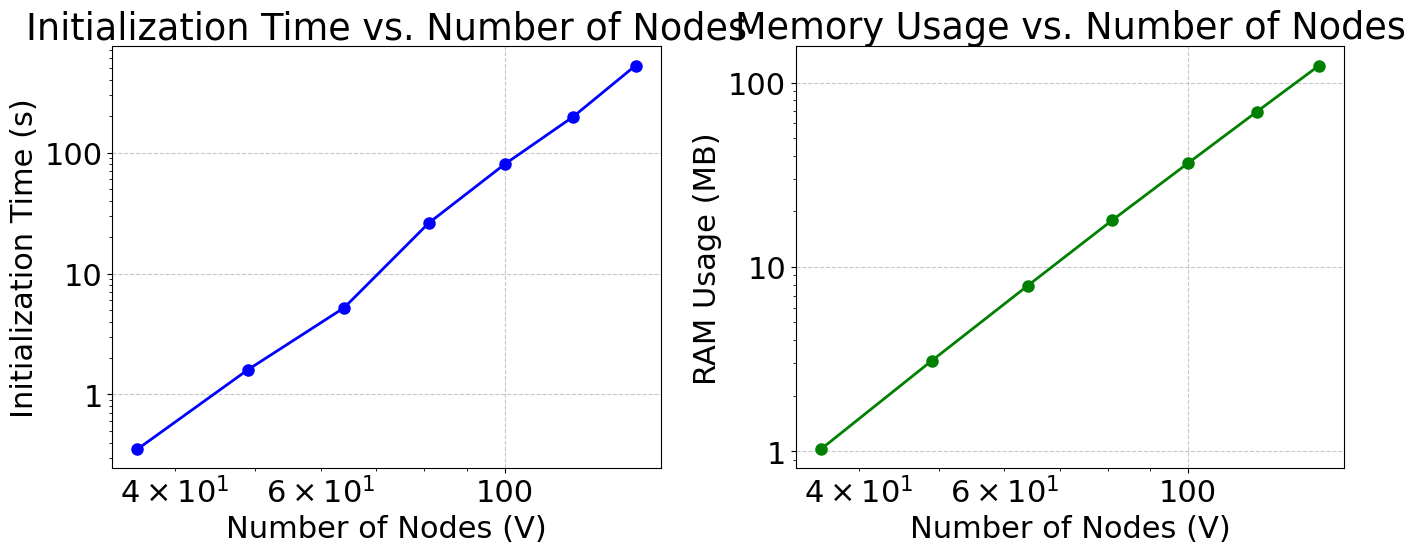

In [4]:
# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot initialization time vs. nodes
ax1.plot(data['Nodes (V)'], data['Init Time (s)'], 'o-', color='blue', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Nodes (V)')
ax1.set_ylabel('Initialization Time (s)')
ax1.set_title('Initialization Time vs. Number of Nodes')
ax1.grid(True, linestyle='--', alpha=0.7)

# Use log scale for y-axis to better visualize exponential growth
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.yaxis.set_major_formatter(ScalarFormatter())
ax1.xaxis.set_major_formatter(ScalarFormatter())

# Plot RAM usage vs. nodes
ax2.plot(data['Nodes (V)'], data['RAM Usage (MB)'], 'o-', color='green', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Nodes (V)')
ax2.set_ylabel('RAM Usage (MB)')
ax2.set_title('Memory Usage vs. Number of Nodes')
ax2.grid(True, linestyle='--', alpha=0.7)

# Use log scale for y-axis
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.yaxis.set_major_formatter(ScalarFormatter())
ax2.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

## Curve Fitting to Determine Complexity

Let's fit polynomial curves to estimate the computational complexity.

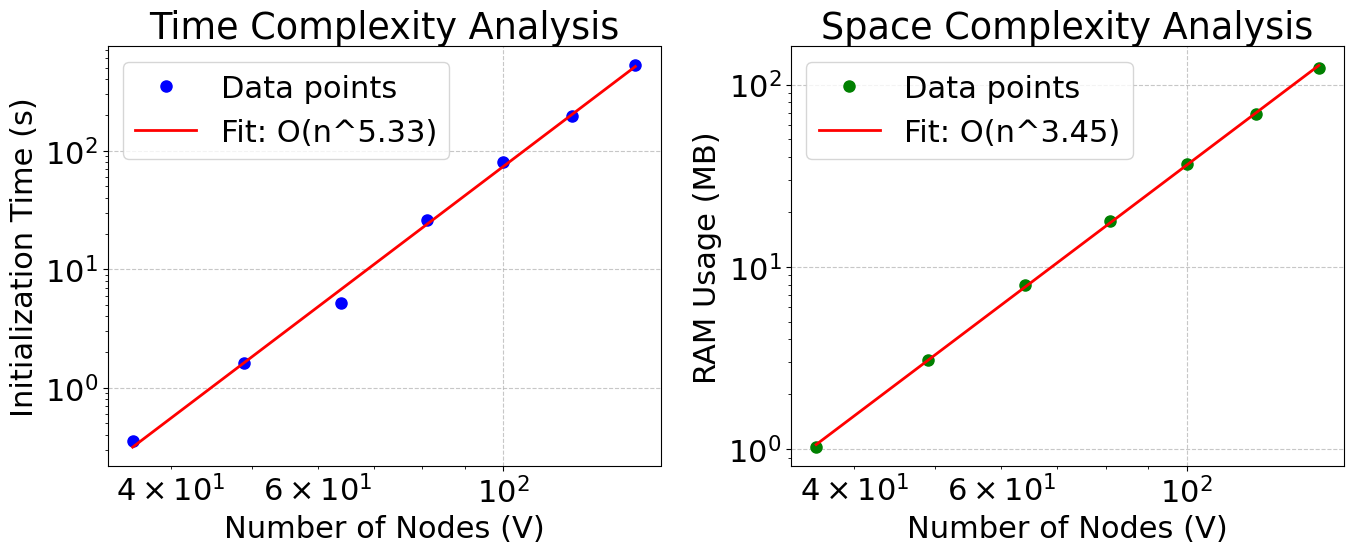

In [5]:
# Fit polynomial curves to the data
nodes = data['Nodes (V)'].values
time = data['Init Time (s)'].values
memory = data['RAM Usage (MB)'].values

# Use logarithmic space for better fitting
log_nodes = np.log(nodes)
log_time = np.log(time)
log_memory = np.log(memory)

# Linear fit in log space (which corresponds to power law in normal space)
time_poly = np.polyfit(log_nodes, log_time, 1)
memory_poly = np.polyfit(log_nodes, log_memory, 1)

# Create function for the fitted curves
def power_law(x, a, b):
    return np.exp(a) * x**b

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot time data and fitted curve
x_range = np.linspace(min(nodes), max(nodes), 100)
ax1.plot(nodes, time, 'o', label='Data points', color='blue', markersize=8)
ax1.plot(x_range, power_law(x_range, time_poly[1], time_poly[0]), 
         '-', label=f'Fit: O(n^{time_poly[0]:.2f})', color='red', linewidth=2)
ax1.set_xlabel('Number of Nodes (V)')
ax1.set_ylabel('Initialization Time (s)')
ax1.set_title('Time Complexity Analysis')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Plot memory data and fitted curve
ax2.plot(nodes, memory, 'o', label='Data points', color='green', markersize=8)
ax2.plot(x_range, power_law(x_range, memory_poly[1], memory_poly[0]), 
         '-', label=f'Fit: O(n^{memory_poly[0]:.2f})', color='red', linewidth=2)
ax2.set_xlabel('Number of Nodes (V)')
ax2.set_ylabel('RAM Usage (MB)')
ax2.set_title('Space Complexity Analysis')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

## Combined Visualization

Let's create a combined plot with both metrics on the same chart using a secondary y-axis.

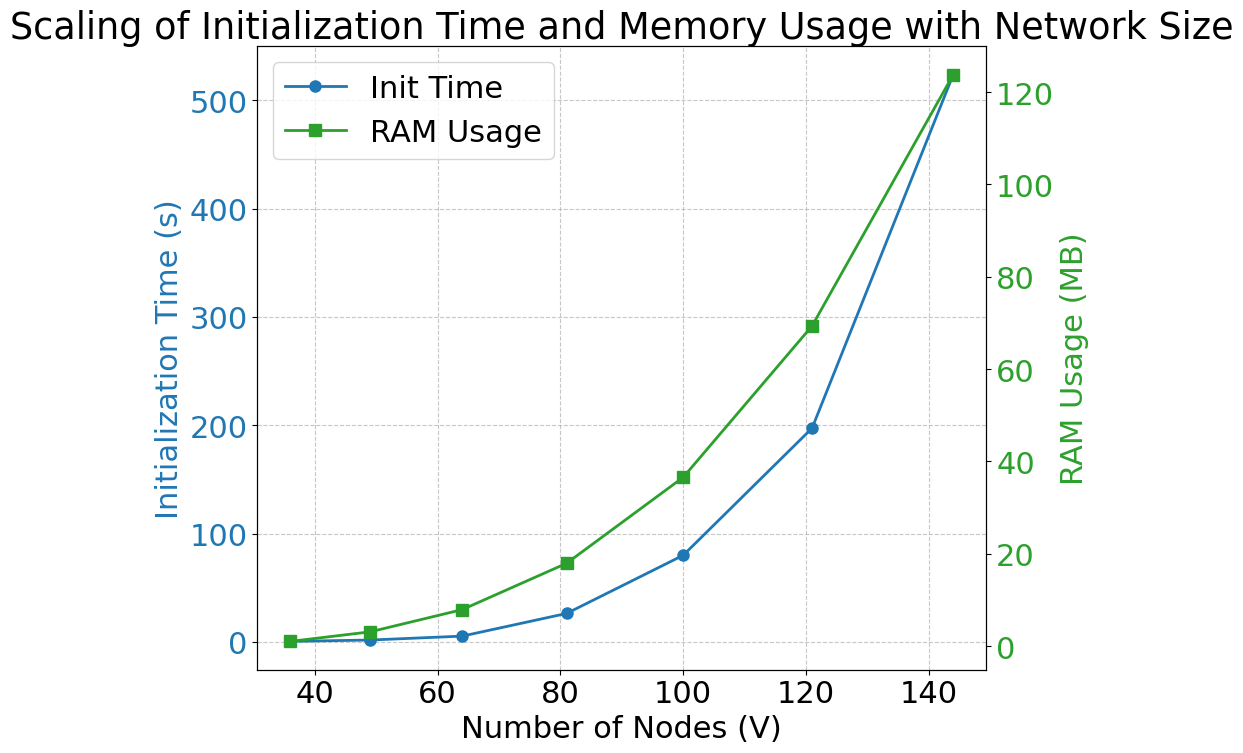

In [6]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot time data on primary axis
color = 'tab:blue'
ax1.set_xlabel('Number of Nodes (V)')
ax1.set_ylabel('Initialization Time (s)', color=color)
ax1.plot(data['Nodes (V)'], data['Init Time (s)'], 'o-', color=color, linewidth=2, markersize=8, label='Init Time')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('RAM Usage (MB)', color=color)
ax2.plot(data['Nodes (V)'], data['RAM Usage (MB)'], 's-', color=color, linewidth=2, markersize=8, label='RAM Usage')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and grid
plt.title('Scaling of Initialization Time and Memory Usage with Network Size')
ax1.grid(True, linestyle='--', alpha=0.7)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Estimated resources for a graph with 10,000 nodes:
Time: 39,379,320.60 days (using O(n^5.33) model)
Memory: 279.85 TB (using O(n^3.45) model)


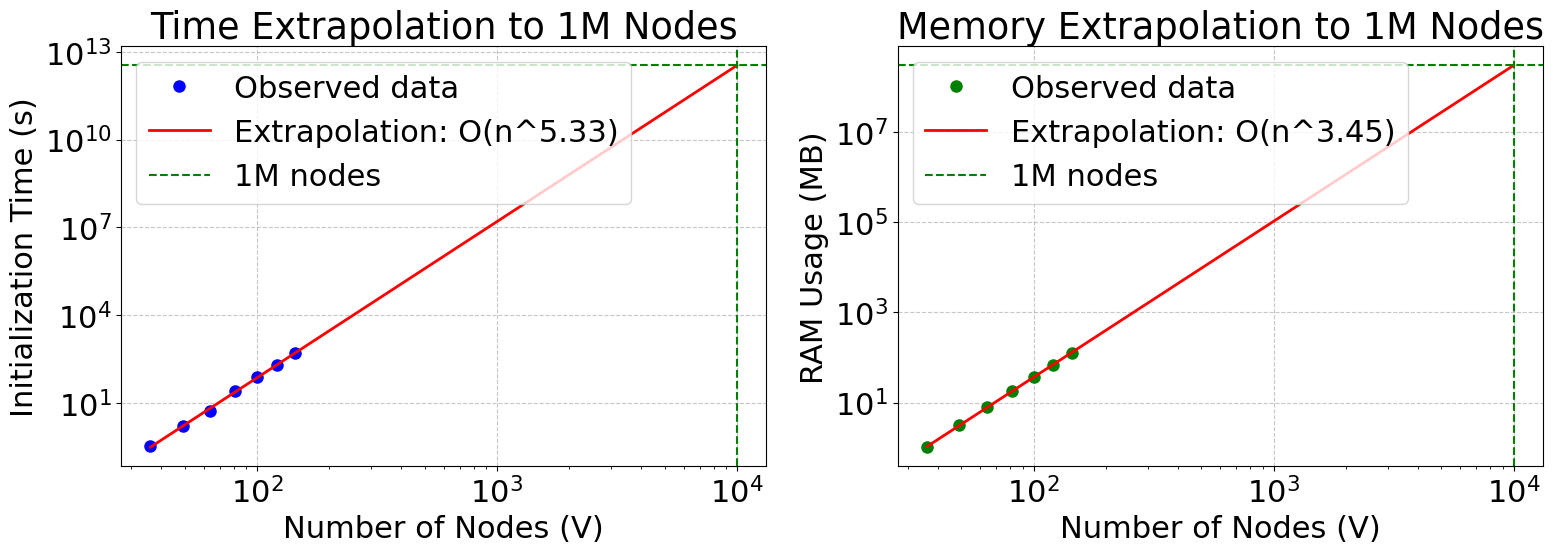


Consider algorithmic improvements or distributed computing approaches.

Consider memory optimization techniques or distributed computing approaches.


In [11]:
# Extrapolate to estimate requirements for a graph with one million nodes
million_nodes = 1_000_0

# Estimate time and memory using our fitted power law models
estimated_time = power_law(million_nodes, time_poly[1], time_poly[0])
estimated_memory = power_law(million_nodes, memory_poly[1], memory_poly[0])

# Convert time to more readable units if needed
if estimated_time > 86400:  # More than a day
    time_unit = "days"
    estimated_time_formatted = estimated_time / 86400
elif estimated_time > 3600:  # More than an hour
    time_unit = "hours"
    estimated_time_formatted = estimated_time / 3600
elif estimated_time > 60:  # More than a minute
    time_unit = "minutes"
    estimated_time_formatted = estimated_time / 60
else:
    time_unit = "seconds"
    estimated_time_formatted = estimated_time

# Convert memory to more readable units
if estimated_memory > 1024 * 1024:  # More than 1 TB
    memory_unit = "TB"
    estimated_memory_formatted = estimated_memory / (1024 * 1024)
elif estimated_memory > 1024:  # More than 1 GB
    memory_unit = "GB"
    estimated_memory_formatted = estimated_memory / 1024
else:
    memory_unit = "MB"
    estimated_memory_formatted = estimated_memory

# Create a formatted output
print(f"Estimated resources for a graph with {million_nodes:,} nodes:")
print(f"Time: {estimated_time_formatted:,.2f} {time_unit} (using O(n^{time_poly[0]:.2f}) model)")
print(f"Memory: {estimated_memory_formatted:,.2f} {memory_unit} (using O(n^{memory_poly[0]:.2f}) model)")

# Create a visualization to put this in context
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Extended node range for extrapolation visualization
node_range = np.logspace(np.log10(min(nodes)), np.log10(million_nodes), 100)

# Plot time extrapolation
ax1.plot(nodes, time, 'o', label='Observed data', color='blue', markersize=8)
ax1.plot(node_range, power_law(node_range, time_poly[1], time_poly[0]), 
         '-', label=f'Extrapolation: O(n^{time_poly[0]:.2f})', color='red', linewidth=2)
ax1.axvline(x=million_nodes, color='green', linestyle='--', label='1M nodes')
ax1.axhline(y=estimated_time, color='green', linestyle='--')
ax1.set_xlabel('Number of Nodes (V)')
ax1.set_ylabel('Initialization Time (s)')
ax1.set_title('Time Extrapolation to 1M Nodes')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Plot memory extrapolation
ax2.plot(nodes, memory, 'o', label='Observed data', color='green', markersize=8)
ax2.plot(node_range, power_law(node_range, memory_poly[1], memory_poly[0]), 
         '-', label=f'Extrapolation: O(n^{memory_poly[0]:.2f})', color='red', linewidth=2)
ax2.axvline(x=million_nodes, color='green', linestyle='--', label='1M nodes')
ax2.axhline(y=estimated_memory, color='green', linestyle='--')
ax2.set_xlabel('Number of Nodes (V)')
ax2.set_ylabel('RAM Usage (MB)')
ax2.set_title('Memory Extrapolation to 1M Nodes')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Add annotations for practical interpretation
if estimated_time > 86400 * 30:  # More than a month
    print("\nWARNING: The estimated time exceeds one month, which may be impractical.")
    print("Consider algorithmic improvements or distributed computing approaches.")

if estimated_memory > 1024 * 128:  # More than 128 GB
    print("\nWARNING: The estimated memory exceeds typical server RAM capacity.")
    print("Consider memory optimization techniques or distributed computing approaches.")